# Proyek Pertama: Menyelesaikan Permasalahan Universitas Jaya Jaya

- Nama: T. Muhammad Caesar Maulana
- Email: caesarm1611@gmail.com
- Id Dicoding: caesarmaulana

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## Data Understanding

### Menyiapkan data yang akan digunakan

In [2]:
# Mengunduh dataset karyawan dari sumber eksternal (GitHub)
url = 'https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/main/students_performance/data.csv'

# Membaca dataset ke dalam DataFrame menggunakan pandas
df = pd.read_csv(url, sep=";")
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
df.rename(columns = {'Nacionality':'Nationality'}, inplace = True) # Ubah nama kolom agar lebih sesuai

In [4]:
df.shape # Melihat ukuran dataset

(4424, 37)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nationality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [6]:
print("Jumlah nilai yang kosong:\n", df.isnull().sum()) # Melihat data yang kosong

Jumlah nilai yang kosong:
 Marital_status                                  0
Application_mode                                0
Application_order                               0
Course                                          0
Daytime_evening_attendance                      0
Previous_qualification                          0
Previous_qualification_grade                    0
Nationality                                     0
Mothers_qualification                           0
Fathers_qualification                           0
Mothers_occupation                              0
Fathers_occupation                              0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarship_holder                              0
Age_at_enrollment      

### Encoding Variabel Kategorikal

Mengubah variabel kategorikal ke dalam format numerik merupakan langkah penting dalam tahap praproses data untuk machine learning. Proses ini memungkinkan model untuk memahami dan memanfaatkan informasi dari variabel tersebut, sehingga analisis menjadi lebih mendalam dan performa prediksi model bisa meningkat secara signifikan.

In [7]:
print(df["Status"].unique()) # Melihat kelas pada status

['Dropout' 'Graduate' 'Enrolled']


In [8]:
# Mengubah data kolom 'Status' menjadi menjadi format numerikal
df['Status'] = df['Status'].map({'Dropout' : 0, 'Enrolled': 1, 'Graduate': 2})

In [9]:
print(df["Status"].unique()) # Melihat data unik pada kolom 'Status'

[0 2 1]


### Analisis Korelasi antara `Status Mahasiswa` dan Fitur Lainnya

Kode `df.corr()['Status']` digunakan untuk menghitung dan menampilkan koefisien korelasi Pearson antara kolom 'Status' dengan semua kolom lainnya dalam dataset. Hasil ini memberikan gambaran tentang seberapa kuat hubungan linier antara status mahasiswa dan tiap fitur lainnya. Nilai korelasi yang mendekati nol menunjukkan bahwa hubungan liniernya lemah atau bahkan tidak ada. Namun perlu diingat, korelasi tidak berarti kausalitas, dan hubungan yang bersifat non-linier tidak akan terdeteksi oleh metode korelasi Pearson ini.

In [10]:
df.corr()['Status']

Marital_status                                 -0.089804
Application_mode                               -0.221747
Application_order                               0.089791
Course                                          0.034219
Daytime_evening_attendance                      0.075107
Previous_qualification                         -0.056039
Previous_qualification_grade                    0.103764
Nationality                                    -0.014801
Mothers_qualification                          -0.043178
Fathers_qualification                          -0.001393
Mothers_occupation                             -0.005629
Fathers_occupation                             -0.001899
Admission_grade                                 0.120889
Displaced                                       0.113986
Educational_special_needs                      -0.007353
Debtor                                         -0.240999
Tuition_fees_up_to_date                         0.409827
Gender                         

Untuk mengeksplorasi hubungan non-linier antara fitur-fitur dan variabel target, menggunakan korelasi peringkat Spearman. Metode ini digunakan untuk menilai sejauh mana hubungan antara dua variabel dapat dijelaskan dengan fungsi monoton, yaitu hubungan yang bergerak searah meskipun tidak harus linier.

In [11]:
# Menghitung korelasi peringkat Spearman terhadap status mahasiswa
korelasi_spearman = df.corr(method='spearman')['Status'].sort_values(ascending=False)

# Menampilkan hasil korelasi Spearman
print("Korelasi Peringkat Spearman terhadap Status Mahasiswa:")
print(korelasi_spearman)

Korelasi Peringkat Spearman terhadap Status Mahasiswa:
Status                                          1.000000
Curricular_units_2nd_sem_approved               0.654049
Curricular_units_1st_sem_approved               0.594194
Curricular_units_2nd_sem_grade                  0.559820
Curricular_units_1st_sem_grade                  0.497341
Tuition_fees_up_to_date                         0.400283
Scholarship_holder                              0.301103
Curricular_units_2nd_sem_enrolled               0.241456
Curricular_units_1st_sem_enrolled               0.230576
Admission_grade                                 0.125791
Displaced                                       0.113241
Previous_qualification_grade                    0.112414
Application_order                               0.102185
Daytime_evening_attendance                      0.073066
GDP                                             0.053497
Curricular_units_2nd_sem_credited               0.035004
Mothers_occupation               

### Pembersihan Dataset

Proses pembersihan dataset bertujuan untuk menyempurnakan data sebelum dianalisis, dengan cara menghapus kolom-kolom yang tidak relevan dan menangani masalah kualitas data. Langkah ini penting agar model hanya mempelajari atribut-atribut yang benar-benar berpengaruh terhadap keberhasilan akademik, sehingga meningkatkan akurasi dan efisiensi prediksi. Kolom-kolom yang ditunjukkan di bawah ini memiliki koefisien korelasi antara -0.05 hingga 0.05 berdasarkan analisis korelasi Spearman dan Pearson, yang mengindikasikan bahwa hubungan mereka dengan 'Status Mahasiswa' sangat lemah.

In [12]:
df = df.drop(columns=[
    'Nationality', 'International', 'Educational_special_needs', 'Course',
    'Mothers_qualification', 'Fathers_qualification',
    'Mothers_occupation', 'Fathers_occupation',
    'Unemployment_rate', 'Inflation_rate'
], axis=1)

In [13]:
# Membuat fitur interaksi antara jumlah mata kuliah yang disetujui di semester 1 dan 2
df['Interaction_CU_1st_2nd_Approved'] = df['Curricular_units_1st_sem_approved'] * df['Curricular_units_2nd_sem_approved']

# Membuat fitur interaksi antara nilai mata kuliah semester 1 dan 2
df['Interaction_CU_1st_2nd_Grade'] = df['Curricular_units_1st_sem_grade'] * df['Curricular_units_2nd_sem_grade']

# Menambahkan fitur agregat total mata kuliah yang disetujui
df['Total_CU_Approved'] = df['Curricular_units_1st_sem_approved'] + df['Curricular_units_2nd_sem_approved']

# Menghitung nilai rata-rata dari semua mata kuliah
df['Total_CU_Grade'] = (df['Curricular_units_1st_sem_grade'] + df['Curricular_units_2nd_sem_grade']) / 2

# Menghapus kolom asli untuk menghindari multikolinearitas dalam model
columns_to_drop = [
    'Curricular_units_1st_sem_approved',
    'Curricular_units_2nd_sem_approved',
    'Curricular_units_1st_sem_grade',
    'Curricular_units_2nd_sem_grade'
]
df.drop(columns=columns_to_drop, axis=1, inplace=True)


### Exploratory Data Analysis (EDA)

EDA merupakan langkah penting dalam memahami dataset secara menyeluruh. Melalui analisis visual dan statistik, EDA membantu mengungkap pola, kejanggalan, serta hubungan antar fitur. Proses ini sangat bermanfaat untuk mengidentifikasi faktor-faktor yang berpengaruh terhadap risiko mahasiswa putus studi, sehingga proses pemodelan selanjutnya bisa dilakukan dengan dasar yang lebih kuat dan terarah.

**Memahami Status Mahasiswa: Proporsi Lulusan, Masih Aktif, dan Dropout**

Diagram lingkaran berikut menggambarkan distribusi status akademik mahasiswa dalam dataset. Terlihat bahwa sebesar 32,12% mahasiswa tidak melanjutkan studinya, menunjukkan tingkat dropout yang cukup tinggi dan perlu mendapat perhatian serta penanganan lebih lanjut.

In [15]:
x = df['Status'].value_counts().index
y = df['Status'].value_counts().values

# Membuat DataFrame status
status_df = pd.DataFrame({
    'Status': x,
    'Count_T': y
})

# Membuat pie chart dengan Plotly dan menampilkan persentase
fig = px.pie(status_df,
             names='Status',
             values='Count_T',
             title='Persentase Mahasiswa: Dropout, Masih Terdaftar, dan Lulus')

# Mengatur tampilan pie chart: lubang di tengah, informasi persentase + label, dan efek tarik sebagian
fig.update_traces(labels=['Lulus', 'Dropout', 'Masih Terdaftar'],
                  hole=0.4,
                  textinfo='percent+label',
                  pull=[0, 0.2, 0.1])

fig.show()

# Menampilkan jumlah mahasiswa per status secara tekstual
status_labels = ['Dropout', 'Enrolled', 'Graduate']
status_counts = df['Status'].value_counts().sort_index()
for idx, label in enumerate(status_labels):
    print(f"{label}: {status_counts.get(idx, 0)} mahasiswa ({status_counts.get(idx, 0) / df.shape[0] * 100:.2f}%)")

Dropout: 1421 mahasiswa (32.12%)
Enrolled: 794 mahasiswa (17.95%)
Graduate: 2209 mahasiswa (49.93%)


**Analisis Menyeluruh terhadap Faktor-Faktor yang Mempengaruhi Status Mahasiswa**

Bagian ini melakukan analisis mendalam terhadap berbagai faktor untuk memahami pengaruhnya terhadap Status Mahasiswa dalam konteks akademik:

- Heatmap matriks korelasi mengungkapkan hubungan yang kompleks antara berbagai variabel.

- Grafik batang 10 fitur teratas dengan korelasi tertinggi terhadap Status Mahasiswa memungkinkan identifikasi cepat terhadap prediktor-prediktor yang paling signifikan.

- Heatmap Faktor Ranker memberi peringkat pada fitur-fitur tersebut sekaligus menyajikan visualisasi yang terurut dan menarik.

Secara keseluruhan, alat-alat visualisasi ini membangun narasi yang kuat mengenai faktor-faktor yang memengaruhi kesuksesan dan retensi mahasiswa di institusi pendidikan.

**Wawasan Korelasi Fitur**

Matriks korelasi pada heatmap memberikan pandangan mendalam mengenai hubungan antara berbagai faktor dan pengaruhnya terhadap Status Mahasiswa. Korelasi negatif antara faktor seperti Usia saat Pendaftaran dan Status Mahasiswa menunjukkan bahwa usia pendaftaran yang lebih tua cenderung berdampak negatif pada status akademik mahasiswa. Sebaliknya, jumlah total Curricular Units yang disetujui menunjukkan korelasi positif yang kuat, yang menyiratkan bahwa keberhasilan dalam menyelesaikan mata kuliah berhubungan erat dengan status mahasiswa yang lebih baik. Meski demikian, interaksi kompleks antara banyak variabel dalam dataset berdimensi tinggi ini membuat isolasi prediktor spesifik untuk Status Mahasiswa menjadi tantangan.

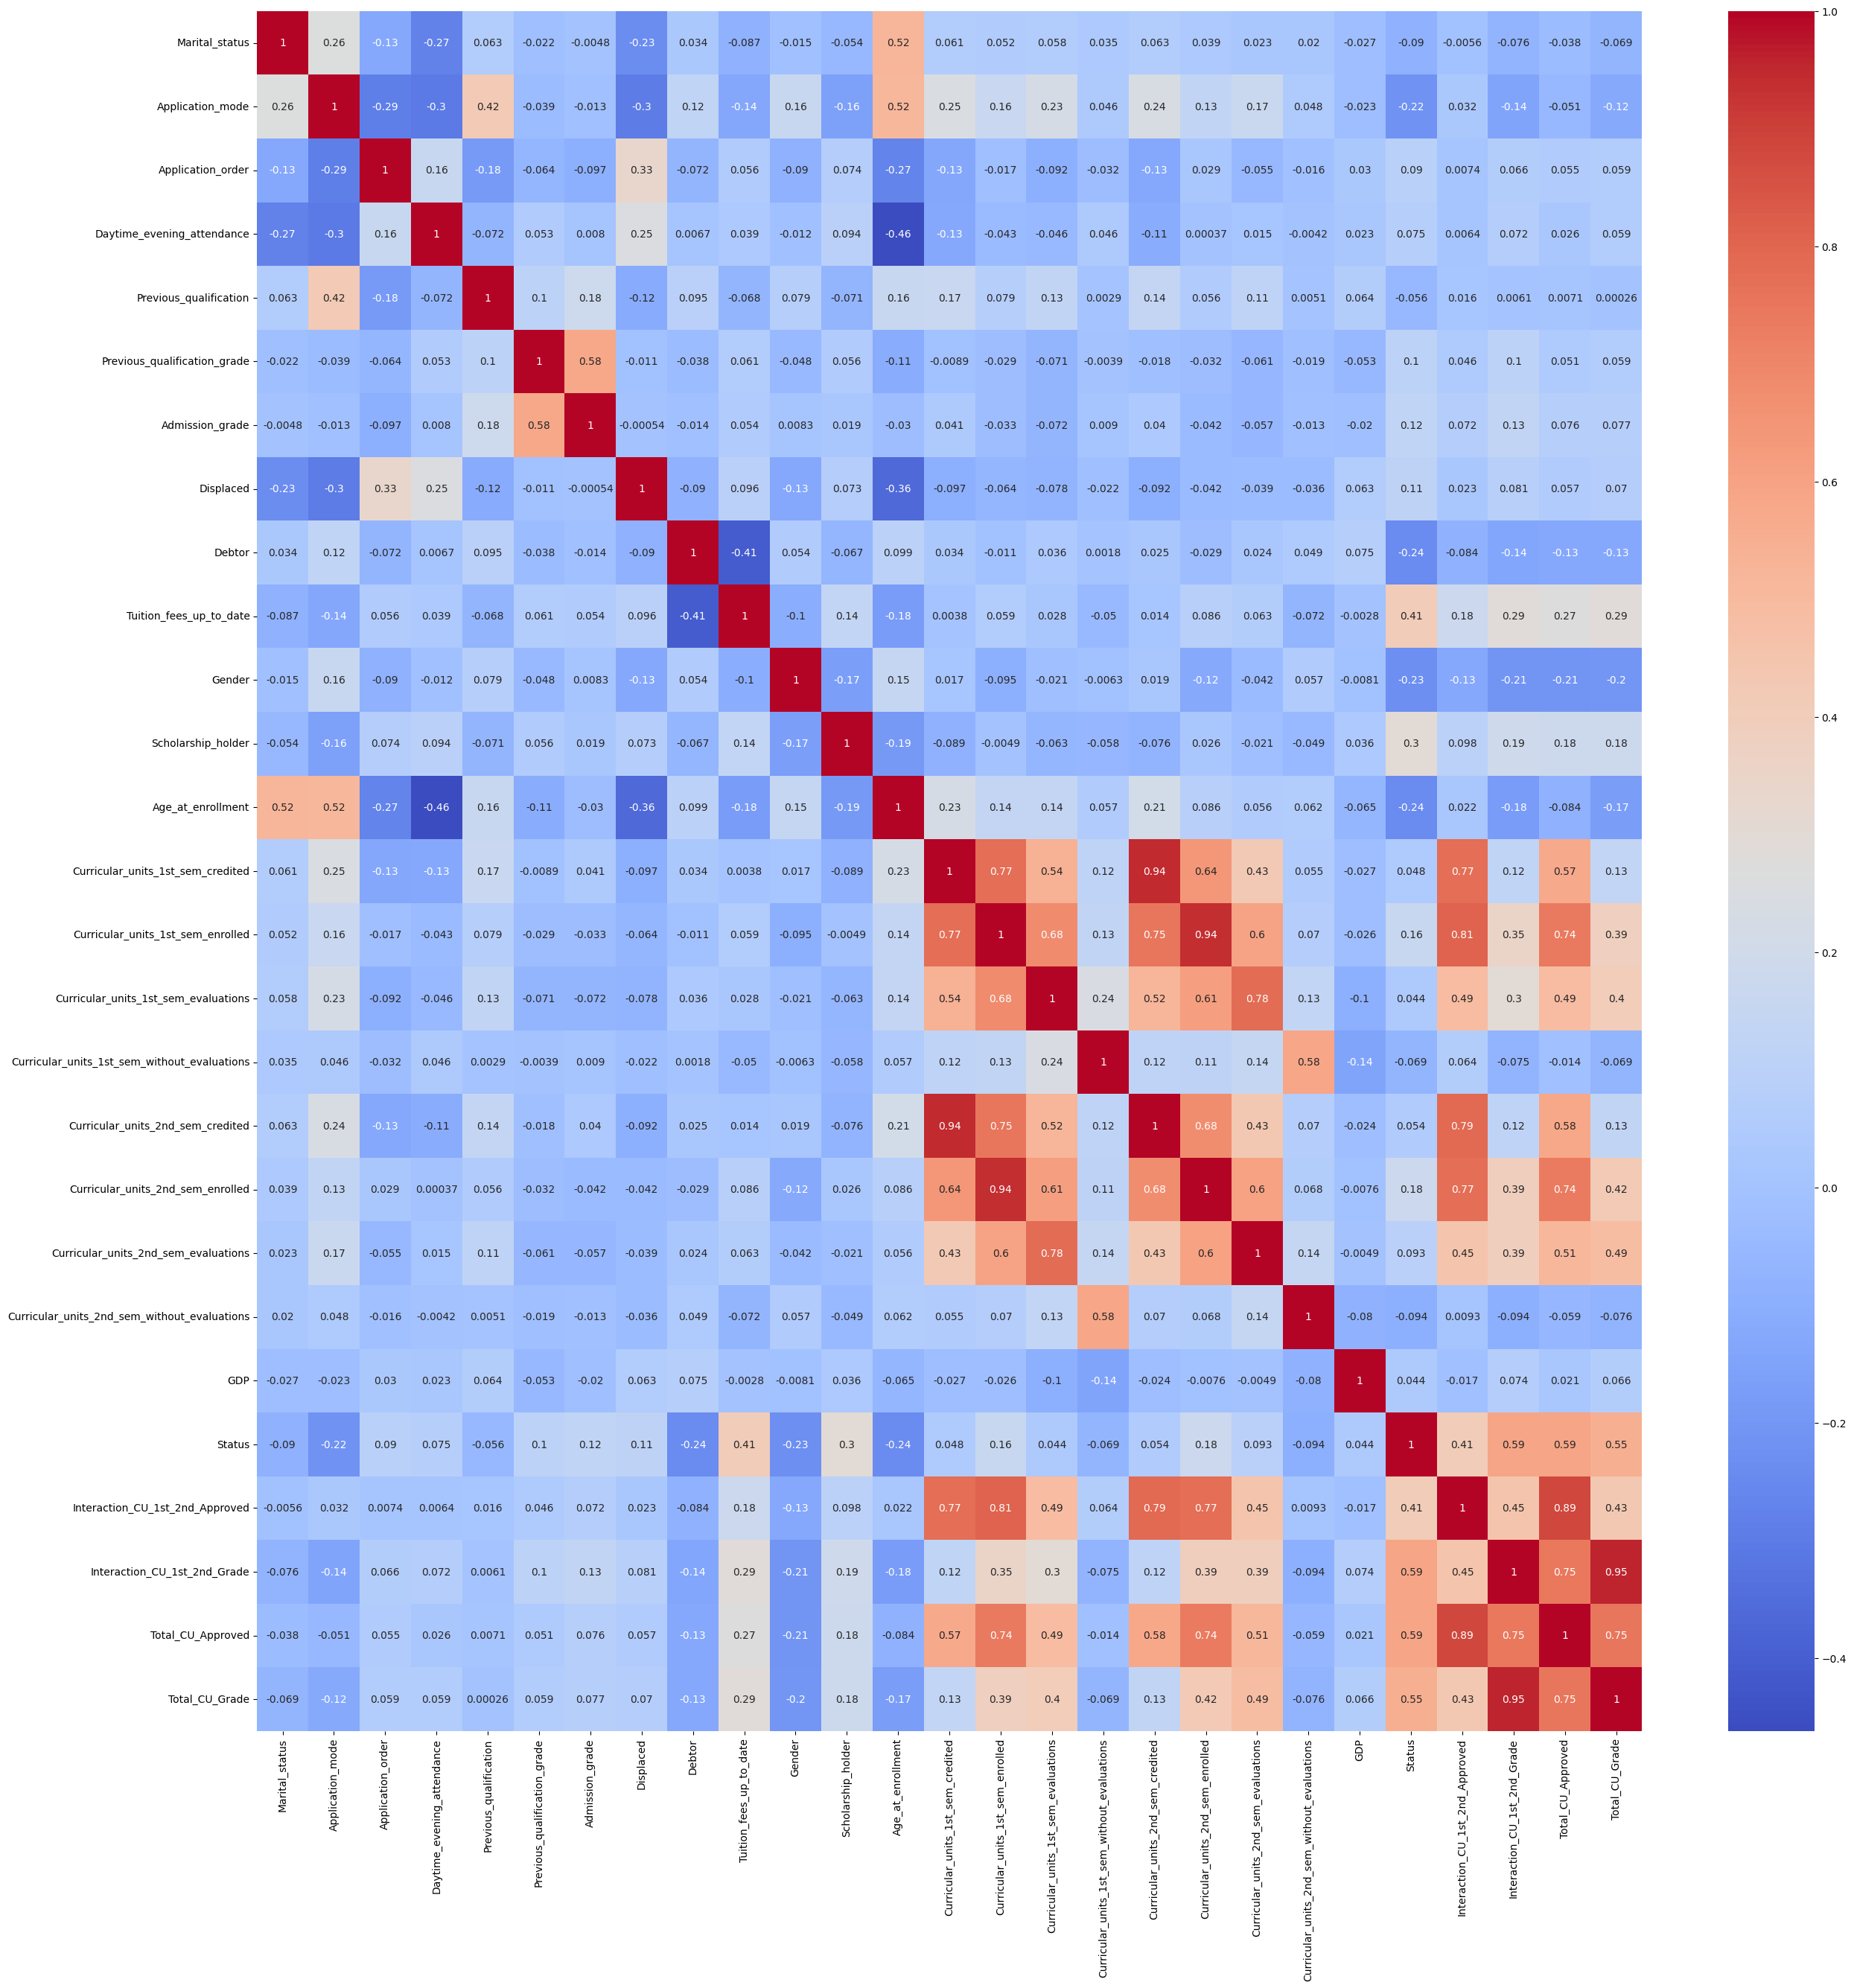

In [ ]:
plt.figure(figsize=(30,30))
ax = sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

**Mengidentifikasi Prediktor Utama untuk Kesuksesan Mahasiswa**

Bagian ini menyajikan analisis statistik yang bertujuan untuk mengidentifikasi 10 fitur teratas yang paling kuat korelasinya dengan Status Mahasiswa. Dengan menghitung korelasi setiap fitur terhadap Status Mahasiswa dan memilih sepuluh fitur dengan nilai absolut tertinggi, menghasilkan peringkat yang jelas. Grafik batang yang dihasilkan menggambarkan hubungan-hubungan ini, memberikan gambaran yang mudah dipahami tentang faktor-faktor mana saja yang paling berpengaruh dalam menentukan Status Mahasiswa, mulai dari metrik kinerja akademik seperti nilai dan persetujuan mata kuliah, hingga faktor finansial seperti Biaya Kuliah dan kepemilikan Beasiswa.

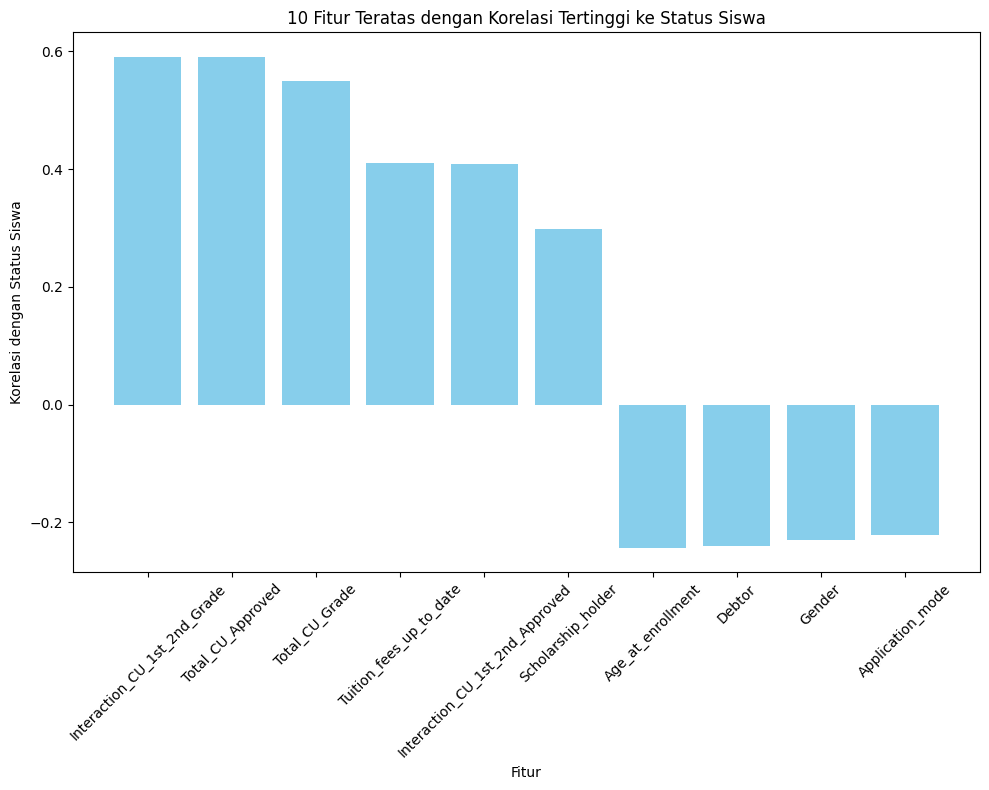

10 Fitur Teratas dengan Korelasi Tertinggi ke Status Siswa:
Interaction_CU_1st_2nd_Grade: 0.5908
Total_CU_Approved: 0.5904
Total_CU_Grade: 0.5504
Tuition_fees_up_to_date: 0.4098
Interaction_CU_1st_2nd_Approved: 0.4093
Scholarship_holder: 0.2976
Age_at_enrollment: -0.2434
Debtor: -0.2410
Gender: -0.2293
Application_mode: -0.2217


In [19]:
# Menghitung korelasi antara fitur dan 'Status' dan menghapus nilai korelasi untuk 'Status' itu sendiri
korelasi = df.corr()['Status'].drop('Status')

# Memilih 10 fitur teratas dengan korelasi tertinggi
fitur_10_teratas = korelasi.abs().nlargest(10).index
nilai_korelasi_10_teratas = korelasi[fitur_10_teratas].values

# Membuat plot untuk 10 fitur teratas
plt.figure(figsize=(10, 8))
plt.bar(x=fitur_10_teratas, height=nilai_korelasi_10_teratas, color='skyblue')
plt.xlabel('Fitur')  # Label untuk sumbu X
plt.ylabel('Korelasi dengan Status Siswa')  # Label untuk sumbu Y
plt.title('10 Fitur Teratas dengan Korelasi Tertinggi ke Status Siswa')  # Judul grafik
plt.xticks(rotation=45)  # Memutar label sumbu X agar lebih mudah dibaca
plt.tight_layout()  # Menyesuaikan layout agar lebih rapat
plt.show()  # Menampilkan grafik

# Menampilkan nama dan nilai korelasi 10 fitur teratas secara tekstual
print("10 Fitur Teratas dengan Korelasi Tertinggi ke Status Siswa:")
for fitur, nilai in zip(fitur_10_teratas, nilai_korelasi_10_teratas):
    print(f"{fitur}: {nilai:.4f}")

**Visualisasi Peringkat Faktor**

Peta panas Factors Ranker memberikan representasi visual yang menarik dan terurut mengenai korelasi antara Status Mahasiswa dan fitur-fitur yang dipilih. Fitur-fitur tersebut diperingkat berdasarkan kekuatan korelasi mereka, dari yang tertinggi hingga yang terendah. Peringkat ini sangat penting untuk mengidentifikasi variabel mana yang paling berpengaruh terhadap Status Mahasiswa, dengan kinerja akademik yang sekali lagi menunjukkan pengaruh yang signifikan. Wawasan-wawasan ini sangat berharga dalam mengembangkan strategi untuk mendukung kesuksesan mahasiswa. Tata letak grafik yang jelas dan anotasi yang diberikan mempermudah pemahaman dan interpretasi data secara langsung.

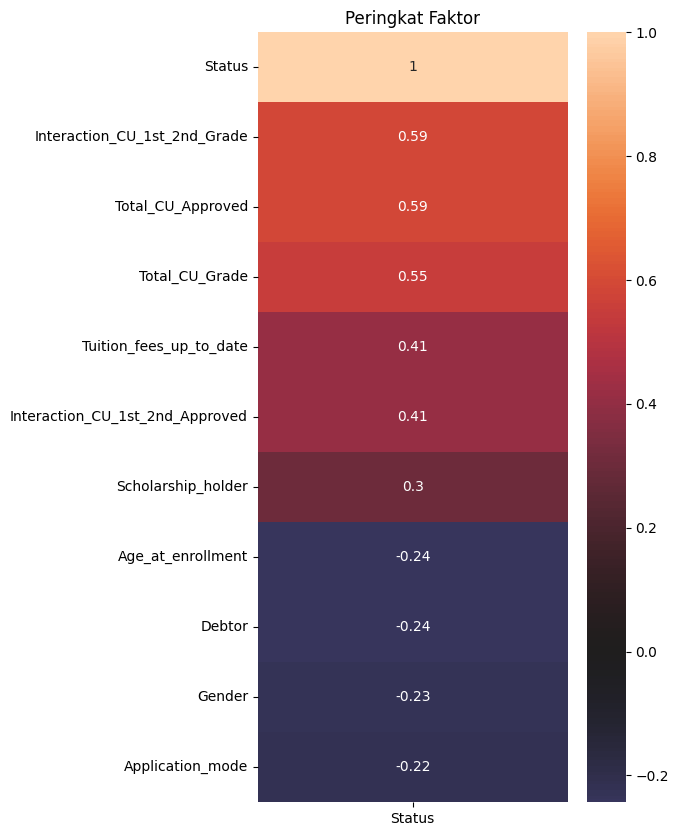

10 Fitur Teratas dengan Korelasi Tertinggi ke Status Siswa:
Interaction_CU_1st_2nd_Grade: 0.5908
Total_CU_Approved: 0.5904
Total_CU_Grade: 0.5504
Tuition_fees_up_to_date: 0.4098
Interaction_CU_1st_2nd_Approved: 0.4093
Scholarship_holder: 0.2976
Age_at_enrollment: -0.2434
Debtor: -0.2410
Gender: -0.2293
Application_mode: -0.2217


In [20]:
# Membuat salinan dari dataframe dengan 10 fitur teratas dan kolom 'Status'
top_10_df = df[fitur_10_teratas.to_list() + ['Status']].copy()

# Menghitung matriks korelasi untuk fitur-fitur ini
top_10_corr = top_10_df.corr()[['Status']]

# Mengurutkan berdasarkan nilai absolut, tetapi tetap mempertahankan tanda untuk menempatkan nilai negatif di bawah nilai positif
sorted_corr = top_10_corr.sort_values(by='Status', key=lambda x: abs(x), ascending=False)

# Membuat heatmap dengan urutan khusus
plt.figure(figsize=(5, 10))
sns.heatmap(sorted_corr, annot=True, center=0)  # Menampilkan angka korelasi pada heatmap
plt.title('Peringkat Faktor')  # Judul heatmap
plt.show()  # Menampilkan heatmap

# Menampilkan nama dan nilai korelasi 10 fitur teratas secara tekstual
print("10 Fitur Teratas dengan Korelasi Tertinggi ke Status Siswa:")
for fitur, nilai in zip(fitur_10_teratas, nilai_korelasi_10_teratas):
    print(f"{fitur}: {nilai:.4f}")

**Kinerja Akademik dan Dampaknya terhadap Status Mahasiswa**

Setelah mengeksplorasi berbagai faktor yang memengaruhi status mahasiswa, bagian ini secara visual menguraikan dampak dari penyelesaian mata kuliah dan nilai terhadap status akademik mahasiswa, kini dengan mempertimbangkan fitur-fitur baru yang mencerminkan efek gabungan dari kedua faktor tersebut.

**Dampak Interaksi antara Nilai Semester 1 dan 2 terhadap Status Mahasiswa**

Grafik batang pertama menunjukkan tren yang jelas, yaitu peningkatan interaksi antara nilai semester pertama dan kedua dari mahasiswa yang drop-out hingga yang lulus. Hal ini mengindikasikan bahwa tidak hanya kinerja individu pada setiap semester yang penting, tetapi juga kinerja gabungan dari kedua semester tersebut menjadi indikator yang kuat untuk kelulusan akhirnya.

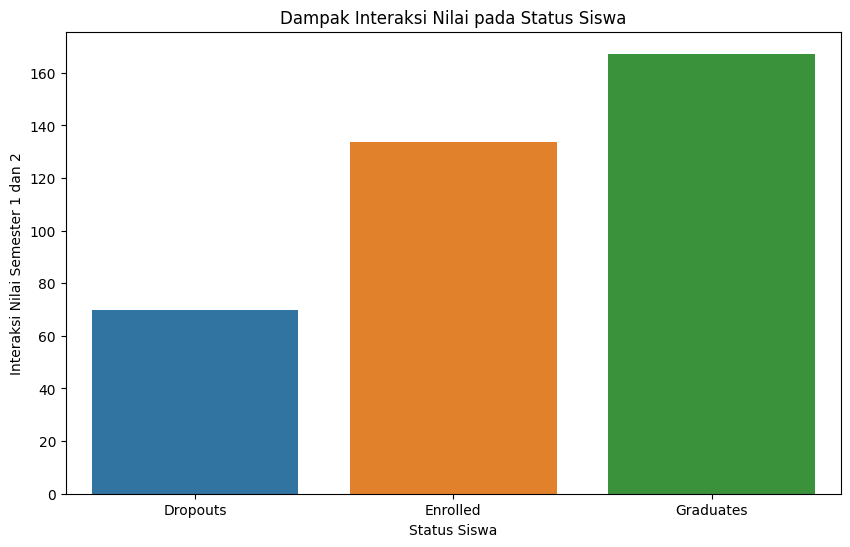

Dropouts: 69.96
Enrolled: 133.68
Graduates: 167.26


In [21]:
# Membuat figure untuk plot dengan ukuran 10x6 inci
plt.figure(figsize=(10, 6))

# Membuat barplot untuk interaksi nilai antara semester pertama dan kedua berdasarkan status siswa
sns.barplot(x='Status', y='Interaction_CU_1st_2nd_Grade', data=df, errorbar=None)

# Menambahkan label pada sumbu X untuk mengganti nilai angka dengan label status siswa
plt.xticks([0, 1, 2], ['Dropouts', 'Enrolled', 'Graduates'])

# Menambahkan label pada sumbu X dan Y
plt.xlabel('Status Siswa')
plt.ylabel('Interaksi Nilai Semester 1 dan 2')

# Menambahkan judul untuk grafik
plt.title('Dampak Interaksi Nilai pada Status Siswa')

# Menampilkan plot
plt.show()

# Menampilkan nilai rata-rata interaksi nilai semester 1 dan 2 untuk setiap status siswa secara tekstual
status_labels = ['Dropouts', 'Enrolled', 'Graduates']
for status in range(3):
    mean_value = df[df['Status'] == status]['Interaction_CU_1st_2nd_Grade'].mean()
    print(f"{status_labels[status]}: {mean_value:.2f}")

**Dampak Total Mata Kuliah yang Disetujui terhadap Status Mahasiswa**

Grafik kedua menunjukkan dampak dari ukuran agregat jumlah mata kuliah yang disetujui di kedua semester. Mirip dengan fitur interaksi, ukuran agregat ini juga dapat memprediksi kemampuan seorang mahasiswa untuk lulus.

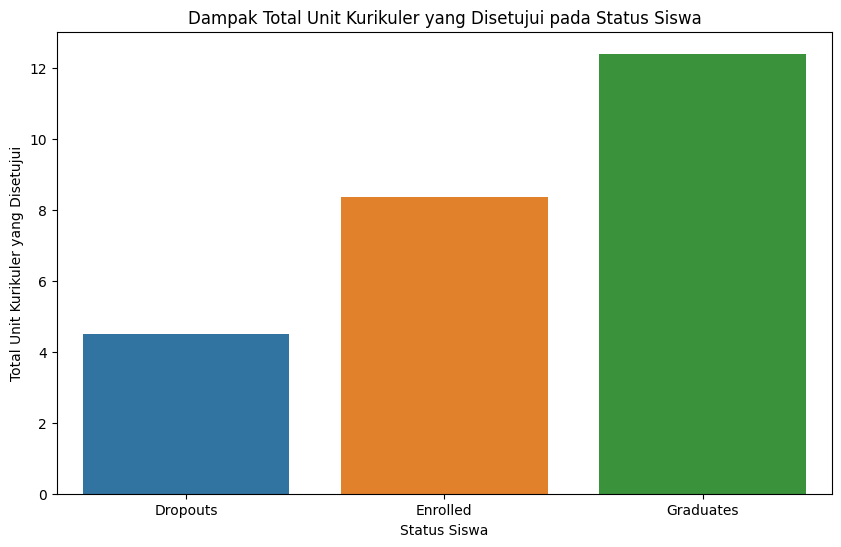

Dropouts: 4.49
Enrolled: 8.38
Graduates: 12.41


In [22]:
# Membuat figure untuk plot dengan ukuran 10x6 inci
plt.figure(figsize=(10, 6))

# Membuat barplot untuk total unit kurikuler yang disetujui berdasarkan status siswa
sns.barplot(x='Status', y='Total_CU_Approved', data=df, errorbar=None)

# Menambahkan label pada sumbu X untuk mengganti nilai angka dengan label status siswa
plt.xticks([0, 1, 2], ['Dropouts', 'Enrolled', 'Graduates'])

# Menambahkan label pada sumbu X dan Y
plt.xlabel('Status Siswa')
plt.ylabel('Total Unit Kurikuler yang Disetujui')

# Menambahkan judul untuk grafik
plt.title('Dampak Total Unit Kurikuler yang Disetujui pada Status Siswa')

# Menampilkan plot
plt.show()

# Menampilkan nilai rata-rata Total_CU_Approved untuk setiap status siswa secara tekstual
for status, label in enumerate(['Dropouts', 'Enrolled', 'Graduates']):
    mean_value = df[df['Status'] == status]['Total_CU_Approved'].mean()
    print(f"{label}: {mean_value:.2f}")



**Menilai Peran Status Keuangan dalam Kemajuan Pendidikan**

Bagian ini menggali peran spesifik kondisi keuangan terhadap pencapaian pendidikan. Melalui analisis terhadap utang, pemberian beasiswa, dan status pembayaran biaya kuliah, bertujuan untuk memahami pengaruh fiskal yang mungkin memengaruhi perjalanan akademik seorang mahasiswa.

**Utang dan Trajektori Pendidikan**

Grafik batang bertumpuk pertama menunjukkan kontras visual yang mencolok antara mahasiswa yang memiliki utang dan yang tidak, di tiga kategori status pendidikan: terdaftar, lulus, dan drop-out. Proporsi mahasiswa yang keluar lebih besar pada kelompok yang memiliki utang, yang menunjukkan adanya efek negatif dari kewajiban keuangan terhadap kelangsungan pendidikan mereka.

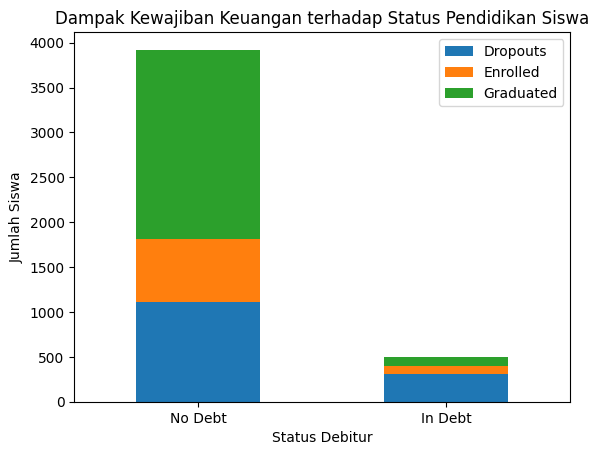

No Debt - Dropouts: 1109 siswa
No Debt - Enrolled: 704 siswa
No Debt - Graduated: 2108 siswa
In Debt - Dropouts: 312 siswa
In Debt - Enrolled: 90 siswa
In Debt - Graduated: 101 siswa


In [25]:
# Menetapkan label deskriptif untuk status siswa
student_status_labels = {0: 'Dropouts', 1: 'Enrolled', 2: 'Graduated'}

# Menetapkan label deskriptif untuk status debitur (siswa dengan hutang)
debtor_status_labels = {0: 'No Debt', 1: 'In Debt'}

# Mengelompokkan data berdasarkan status debitur dan status siswa
grouped = df.groupby(['Debtor', 'Status']).size().unstack()

# Mengganti indeks dengan label yang lebih deskriptif
grouped.rename(index=debtor_status_labels, inplace=True)

# Membuat grafik batang bertumpuk untuk menunjukkan pengaruh status keuangan terhadap status pendidikan siswa
grouped_plot = grouped.plot(kind='bar', stacked=True)

# Menambahkan label pada sumbu X dan Y
plt.xlabel('Status Debitur')
plt.ylabel('Jumlah Siswa')

# Menambahkan judul pada grafik
plt.title('Dampak Kewajiban Keuangan terhadap Status Pendidikan Siswa')

# Menambahkan legenda dengan label yang sudah diperbarui untuk status siswa
plt.legend(labels=[student_status_labels.get(item, item) for item in grouped.columns])

# Menyesuaikan tampilan pada sumbu X agar tidak miring
plt.xticks(rotation=0)

# Menampilkan grafik
plt.show()

# Menampilkan jumlah siswa untuk setiap kombinasi status debitur dan status siswa secara tekstual
for debtor_status, row in grouped.iterrows():
    for status, count in row.items():
        print(f"{debtor_status} - {student_status_labels[status]}: {count} siswa")

**Beasiswa sebagai Sistem Dukungan**

Selanjutnya, dampak dari beasiswa dianalisis melalui grafik batang bertumpuk lainnya. Distribusi data dengan jelas menunjukkan bahwa mayoritas penerima beasiswa lulus, yang dapat mengindikasikan bahwa dukungan finansial merupakan faktor signifikan yang membantu mahasiswa menyelesaikan pendidikan mereka.

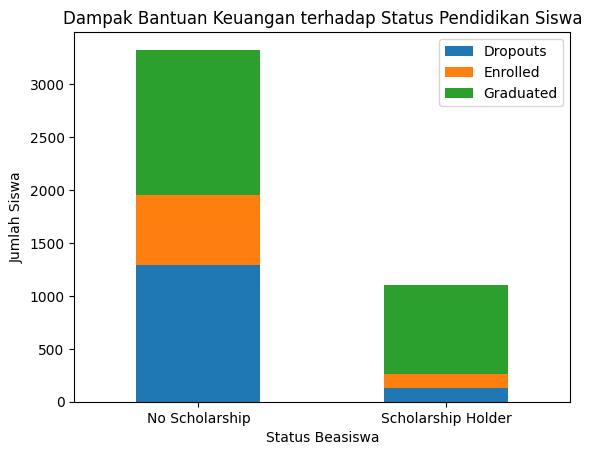

No Scholarship - Dropouts: 1287 siswa
No Scholarship - Enrolled: 664 siswa
No Scholarship - Graduated: 1374 siswa
Scholarship Holder - Dropouts: 134 siswa
Scholarship Holder - Enrolled: 130 siswa
Scholarship Holder - Graduated: 835 siswa


In [26]:
# Menetapkan label deskriptif untuk status beasiswa
scholarship_status_labels = {0: 'No Scholarship', 1: 'Scholarship Holder'}

# Mengelompokkan data berdasarkan status beasiswa dan status siswa
grouped = df.groupby(['Scholarship_holder', 'Status']).size().unstack()

# Mengganti indeks dengan label yang lebih deskriptif
grouped.rename(index=scholarship_status_labels, inplace=True)

# Membuat grafik batang bertumpuk untuk menunjukkan pengaruh beasiswa terhadap status pendidikan siswa
grouped_plot = grouped.plot(kind='bar', stacked=True)

# Menambahkan label pada sumbu X dan Y
plt.xlabel('Status Beasiswa')
plt.ylabel('Jumlah Siswa')

# Menambahkan judul pada grafik
plt.title('Dampak Bantuan Keuangan terhadap Status Pendidikan Siswa')

# Menambahkan legenda dengan label yang sudah diperbarui untuk status siswa
plt.legend(labels=[student_status_labels.get(item, item) for item in grouped.columns])

# Menyesuaikan tampilan pada sumbu X agar tidak miring
plt.xticks(rotation=0)

# Menampilkan grafik
plt.show()

# Menampilkan jumlah siswa untuk setiap kombinasi status beasiswa dan status siswa secara tekstual
for scholarship_status, row in grouped.iterrows():
    for status, count in row.items():
        print(f"{scholarship_status} - {student_status_labels[status]}: {count} siswa")

**Biaya Kuliah: Indikator Finansial yang Prediktif**

Analisis terakhir berfokus pada korelasi antara status pembayaran biaya kuliah dan hasil pendidikan mahasiswa. Grafik menunjukkan bahwa mahasiswa dengan tunggakan biaya kuliah memiliki kemungkinan lebih tinggi untuk drop-out, menjadikan faktor ini sebagai prediktor kuat terhadap penghentian pendidikan.

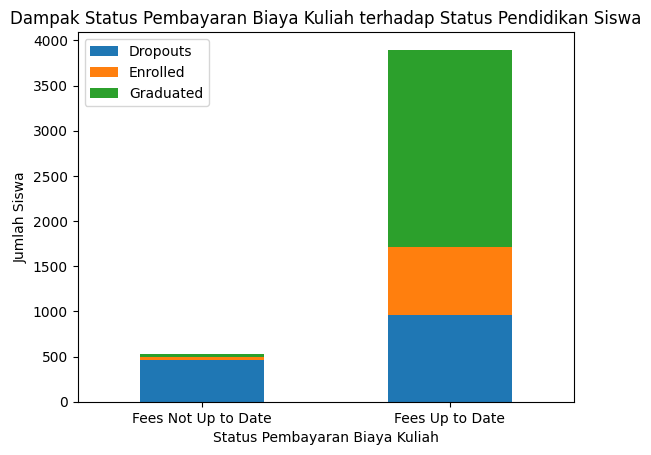

Fees Not Up to Date - Dropouts: 457 siswa
Fees Not Up to Date - Enrolled: 42 siswa
Fees Not Up to Date - Graduated: 29 siswa
Fees Up to Date - Dropouts: 964 siswa
Fees Up to Date - Enrolled: 752 siswa
Fees Up to Date - Graduated: 2180 siswa


In [27]:
# Menetapkan label deskriptif untuk status pembayaran biaya kuliah
tuition_fee_status_labels = {0: 'Fees Not Up to Date', 1: 'Fees Up to Date'}

# Mengelompokkan data berdasarkan status pembayaran biaya kuliah dan status siswa
grouped = df.groupby(['Tuition_fees_up_to_date', 'Status']).size().unstack()

# Mengganti indeks dengan label yang lebih deskriptif
grouped.rename(index=tuition_fee_status_labels, inplace=True)

# Membuat grafik batang bertumpuk untuk menunjukkan pengaruh status pembayaran biaya kuliah terhadap status pendidikan siswa
grouped_plot = grouped.plot(kind='bar', stacked=True)

# Menambahkan label pada sumbu X dan Y
plt.xlabel('Status Pembayaran Biaya Kuliah')
plt.ylabel('Jumlah Siswa')

# Menambahkan judul pada grafik
plt.title('Dampak Status Pembayaran Biaya Kuliah terhadap Status Pendidikan Siswa')

# Menambahkan legenda dengan label yang sudah diperbarui untuk status siswa
plt.legend(labels=[student_status_labels.get(item, item) for item in grouped.columns])

# Menyesuaikan tampilan pada sumbu X agar tidak miring
plt.xticks(rotation=0)

# Menampilkan grafik
plt.show()

# Menampilkan jumlah siswa untuk setiap kombinasi status pembayaran biaya kuliah dan status siswa secara tekstual
for fee_status, row in grouped.iterrows():
    for status, count in row.items():
        print(f"{fee_status} - {student_status_labels[status]}: {count} siswa")

**Interaksi Usia dan Gender dalam Proses Akademik**

Bagian ini menyelidiki dampak faktor demografis, khususnya usia dan gender, terhadap status akademik mahasiswa. Dengan menganalisis distribusi usia saat pendaftaran dan hubungan antara usia dan status mahasiswa, serta dinamika gender, bertujuan untuk mengungkap pola-pola yang mungkin berpengaruh dalam pencapaian pendidikan dan retensi mahasiswa.

**Analisis Distribusi Usia**

Histogram menggambarkan distribusi usia pada saat pendaftaran di kalangan populasi mahasiswa. Sebagian besar mahasiswa mendaftar pada rentang usia sekitar 18 hingga 22 tahun, yang menunjukkan distribusi yang miring dan menyoroti demografi mahasiswa yang umumnya berusia college-age. Tren ini berkurang secara signifikan seiring dengan bertambahnya usia, yang menunjukkan bahwa sistem akademik cenderung lebih fokus pada mahasiswa yang lebih muda.

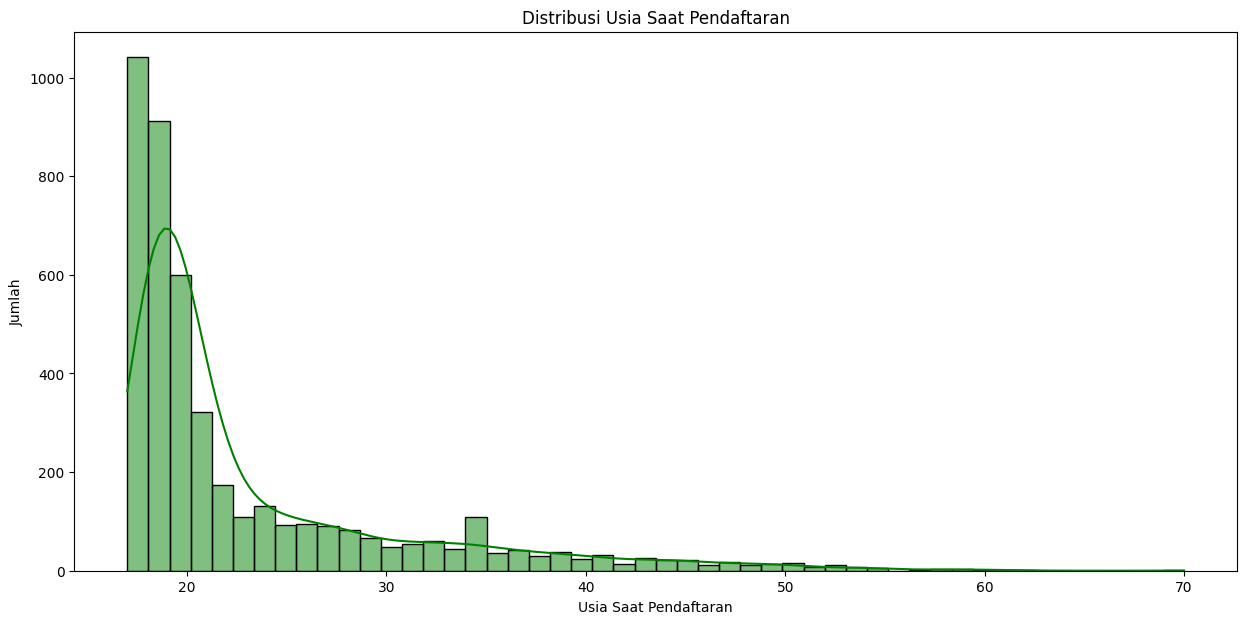

Statistik Usia Saat Pendaftaran:
Usia minimum: 17
Usia maksimum: 70
Usia rata-rata: 23.27
Usia median: 20.0
Usia modus: 18


In [28]:
# Mengganti nilai yang tidak valid (np.inf dan -np.inf) pada kolom 'Age_at_enrollment' dengan NaN
df['Age_at_enrollment'] = df['Age_at_enrollment'].replace([np.inf, -np.inf], np.nan)

# Membuat histogram untuk distribusi usia saat pendaftaran
plt.figure(figsize=(15, 7))
ax = sns.histplot(df['Age_at_enrollment'], bins=50, color='g', kde=True)

# Menambahkan judul dan label sumbu
ax.set_title('Distribusi Usia Saat Pendaftaran')
ax.set_xlabel('Usia Saat Pendaftaran')
ax.set_ylabel('Jumlah')

# Menampilkan grafik
plt.show()

# Menampilkan nilai statistik deskriptif usia saat pendaftaran secara tekstual
print("Statistik Usia Saat Pendaftaran:")
print(f"Usia minimum: {df['Age_at_enrollment'].min()}")
print(f"Usia maksimum: {df['Age_at_enrollment'].max()}")
print(f"Usia rata-rata: {df['Age_at_enrollment'].mean():.2f}")
print(f"Usia median: {df['Age_at_enrollment'].median()}")
print(f"Usia modus: {df['Age_at_enrollment'].mode()[0]}")

**Dinamika Usia dalam Hasil Pendidikan Mahasiswa**

Plot kotak (box plot) menunjukkan distribusi usia terkait dengan status mahasiswa, mengkategorikan mahasiswa menjadi lulus, drop-out, dan yang masih terdaftar. Mahasiswa yang lulus cenderung lebih muda, dengan rentang usia yang lebih sempit, yang menunjukkan jalur yang lebih seragam menuju kelulusan. Sebaliknya, mahasiswa yang drop-out memiliki rentang usia yang lebih lebar, yang mengindikasikan bahwa fenomena drop-out memengaruhi demografi yang lebih luas. Mahasiswa yang masih terdaftar memiliki usia yang hampir serupa dengan mahasiswa yang lulus, menunjukkan bahwa usia pendaftaran tetap konsisten.

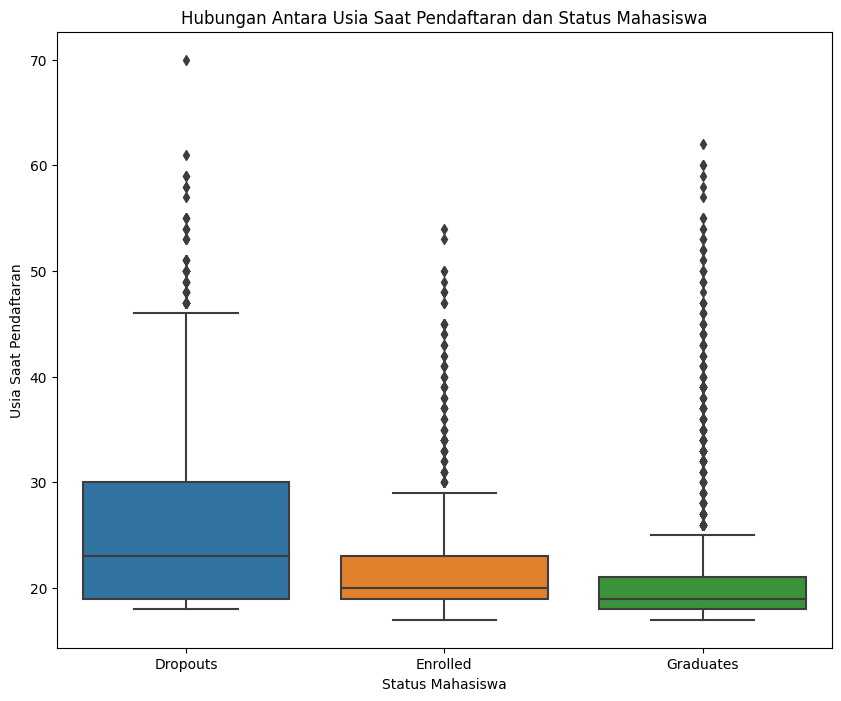

Dropouts:
  Usia minimum: 18
  Usia maksimum: 70
  Usia rata-rata: 26.07
  Usia median: 23.0
  Usia modus: 19

Enrolled:
  Usia minimum: 17
  Usia maksimum: 54
  Usia rata-rata: 22.37
  Usia median: 20.0
  Usia modus: 18

Graduates:
  Usia minimum: 17
  Usia maksimum: 62
  Usia rata-rata: 21.78
  Usia median: 19.0
  Usia modus: 18



In [29]:
# Membuat boxplot untuk melihat hubungan antara usia saat pendaftaran dan status mahasiswa
plt.figure(figsize=(10, 8))
sns.boxplot(x='Status', y='Age_at_enrollment', data=df)

# Menyesuaikan label pada sumbu X untuk menampilkan status mahasiswa
plt.xticks([0, 1, 2], ['Dropouts', 'Enrolled', 'Graduates'])

# Menambahkan label pada sumbu X, sumbu Y, dan judul grafik
plt.xlabel('Status Mahasiswa')
plt.ylabel('Usia Saat Pendaftaran')
plt.title('Hubungan Antara Usia Saat Pendaftaran dan Status Mahasiswa')

# Menampilkan grafik
plt.show()

# Menampilkan nilai statistik deskriptif usia saat pendaftaran untuk setiap status mahasiswa secara tekstual
status_labels = ['Dropouts', 'Enrolled', 'Graduates']
for status in range(3):
    usia = df[df['Status'] == status]['Age_at_enrollment']
    print(f"{status_labels[status]}:")
    print(f"  Usia minimum: {usia.min()}")
    print(f"  Usia maksimum: {usia.max()}")
    print(f"  Usia rata-rata: {usia.mean():.2f}")
    print(f"  Usia median: {usia.median()}")
    print(f"  Usia modus: {usia.mode()[0] if not usia.mode().empty else 'N/A'}\n")

**Pengaruh Gender terhadap Trajektori Pendidikan**

Plot hitung (count plot) menganalisis distribusi status mahasiswa berdasarkan gender, yang mengungkapkan bahwa meskipun jumlah total pria dan wanita mungkin serupa, status akademik mereka berbeda. Visual ini menunjukkan adanya potensi disparitas berbasis gender dalam ketekunan akademik atau keberhasilan, yang perlu dieksplorasi lebih lanjut.

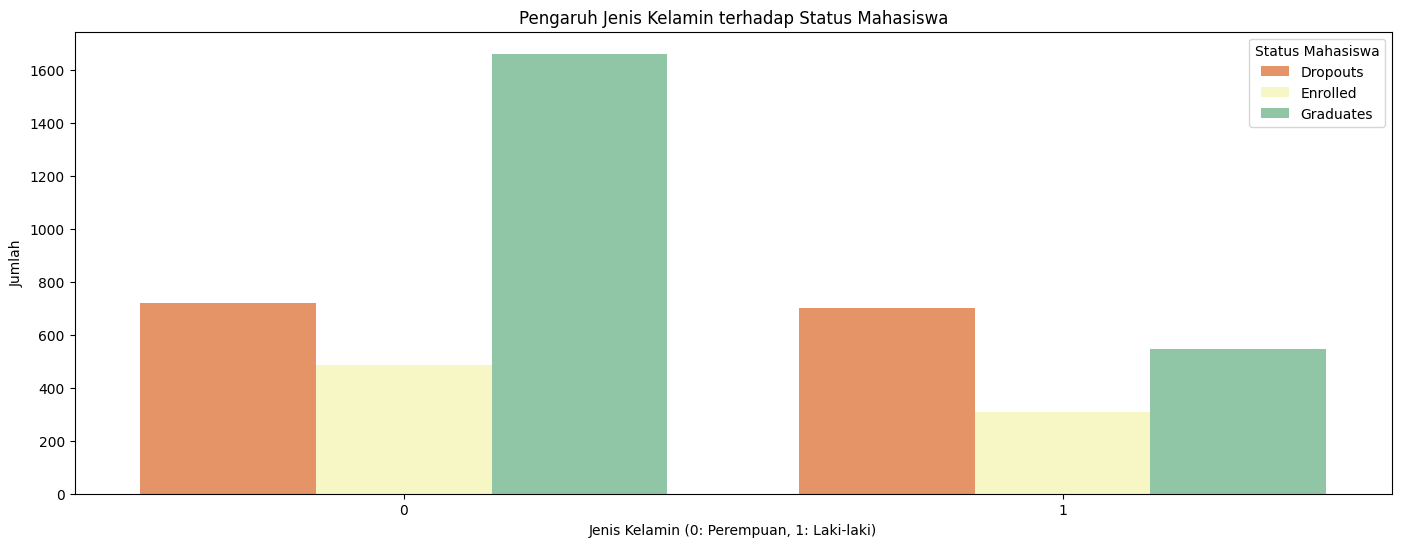

Perempuan - Dropouts: 720 mahasiswa
Perempuan - Enrolled: 487 mahasiswa
Perempuan - Graduates: 1661 mahasiswa
Laki-laki - Dropouts: 701 mahasiswa
Laki-laki - Enrolled: 307 mahasiswa
Laki-laki - Graduates: 548 mahasiswa


In [30]:
# Membuat countplot untuk melihat distribusi status mahasiswa berdasarkan gender
plt.figure(figsize=(17, 6))
sns.countplot(x='Gender', hue='Status', data=df, palette='Spectral')

# Menambahkan label pada sumbu X dan Y
plt.xlabel('Jenis Kelamin (0: Perempuan, 1: Laki-laki)')
plt.ylabel('Jumlah')

# Menambahkan legenda dengan keterangan status mahasiswa
plt.legend(title='Status Mahasiswa', labels=['Dropouts', 'Enrolled', 'Graduates'])

# Menambahkan judul untuk grafik
plt.title('Pengaruh Jenis Kelamin terhadap Status Mahasiswa')

# Menampilkan grafik
plt.show()

# Menampilkan jumlah mahasiswa untuk setiap kombinasi gender dan status mahasiswa secara tekstual
for gender in sorted(df['Gender'].unique()):
    for status in sorted(df['Status'].unique()):
        count = df[(df['Gender'] == gender) & (df['Status'] == status)].shape[0]
        gender_label = 'Perempuan' if gender == 0 else 'Laki-laki'
        status_label = ['Dropouts', 'Enrolled', 'Graduates'][status]
        print(f"{gender_label} - {status_label}: {count} mahasiswa")

**Kesimpulan Hasil Exploratory Data Analysis (EDA)**

1. **Distribusi Status Mahasiswa**
- **Lulus:** 49,93%
- **Dropout:** 32,12%
- **Masih Terdaftar:** 17,95%

Mayoritas mahasiswa berhasil lulus, namun tingkat dropout masih cukup tinggi. Hal ini menandakan perlunya perhatian khusus terhadap faktor-faktor penyebab mahasiswa tidak menyelesaikan studi.

2. **Fitur dengan Korelasi Tertinggi ke Status Mahasiswa**
- **Akademik:**  
  - Interaksi nilai mata kuliah semester 1 & 2  
  - Total mata kuliah yang disetujui  
  - Total nilai
- **Keuangan:**  
  - Status pembayaran biaya kuliah  
  - Kepemilikan beasiswa  
  - Status debitur
- **Demografi:**  
  - Usia saat pendaftaran (korelasi negatif)  
  - Gender (korelasi negatif)  
  - Mode pendaftaran

Faktor akademik dan keuangan menjadi penentu utama keberhasilan studi.

3.  **Dampak Kinerja Akademik**
Mahasiswa dropout rata-rata memiliki nilai interaksi dan jumlah mata kuliah yang disetujui jauh lebih rendah dibandingkan mahasiswa yang lulus atau masih terdaftar. Kinerja akademik sejak awal perkuliahan sangat penting untuk meningkatkan peluang kelulusan.

4. **Dampak Faktor Keuangan**
- Mahasiswa tanpa utang dan yang rutin membayar biaya kuliah cenderung lebih sering lulus.
- Mahasiswa dengan utang atau tunggakan biaya kuliah lebih banyak yang dropout.
- Kepemilikan beasiswa terbukti membantu meningkatkan angka kelulusan.

5. **Statistik Usia Saat Pendaftaran**
- **Usia rata-rata saat mendaftar:** 23 tahun
- Mahasiswa dropout cenderung lebih tua dibandingkan yang lulus.
- Semakin tua usia saat masuk, semakin besar risiko tidak menyelesaikan studi.

6. *Distribusi Gender dan Status Mahasiswa**
- Mahasiswa perempuan lebih banyak yang lulus dibandingkan laki-laki.
- Angka dropout laki-laki dan perempuan relatif seimbang.
- Perlu intervensi spesifik berbasis gender untuk meningkatkan keberhasilan studi.

**Kesimpulan Umum**
Mayoritas mahasiswa berhasil lulus, namun tingkat dropout masih perlu mendapat perhatian. Faktor akademik dan keuangan menjadi penentu utama keberhasilan studi, sementara usia saat pendaftaran dan gender juga berperan meski tidak sebesar faktor lainnya. Hasil EDA ini dapat menjadi dasar dalam merancang strategi untuk menurunkan angka dropout dan meningkatkan tingkat kelulusan mahasiswa.


## Data Preparation / Preprocessing

**Analisis Prediktif Komprehensif untuk Penentuan Status Mahasiswa**

Bagian ini menguraikan alur kerja pemodelan prediktif, yang mencakup pengumpulan data, persiapan, pemilihan model, pelatihan, evaluasi, dan penyempurnaan. Tujuannya adalah untuk memprediksi status mahasiswa (misalnya, Terdaftar, Dropout, Lulus) berdasarkan berbagai fitur input. Pendekatan ini mengintegrasikan berbagai teknik pembelajaran mesin untuk memastikan prediksi yang akurat dan wawasan yang mendalam, yang akan membantu proses pengambilan keputusan di lingkungan pendidikan.

**Mempersiapkan Dataset untuk Pemodelan Prediktif**

Langkah ini melibatkan pembagian dataset menjadi fitur (X) dan variabel target (y), di mana variabel target adalah 'Status Mahasiswa' dari mahasiswa. Dataset kemudian dibagi menjadi set pelatihan dan set pengujian untuk menilai kinerja model pada data yang belum pernah dilihat sebelumnya.

Assertion

As we are predicting whether a student will dropout or not so, the number of "Enrolled" student is irrelevant. We only need to know whether a student graduated or dropedout. So, we are dropping the "Enrolled" values and going forward with "Graduate" & "Dropout" values.

In [ ]:
# Menyalin DataFrame asli untuk mempertahankan dataset awal
df_baru = df.copy()  # Salin dataset asli agar tidak merusak data asli

df_baru.drop(df[df['Status'] == 1].index, inplace = True)

# Mengubah kolom 'Status' menjadi fitur biner 'Dropout'
df_baru['Dropout'] = df_baru['Status'].map(lambda x: 1 if x == 0 else 0)  # Mengubah Status menjadi biner, 1 untuk Dropout dan 0 untuk Enrolled/Graduate

# Menghapus kolom 'Status'
df_baru.drop(['Status'], axis=1, inplace=True)  # Hapus kolom 'Status' setelah konversi menjadi 'Dropout'



In [ ]:
# Membuat objek StandardScaler untuk melakukan standardisasi fitur
scaler = StandardScaler()

# Melakukan standardisasi pada 26 fitur pertama dari dataframe
X = scaler.fit_transform(df_baru.iloc[:, :26].values)

# Membuat folder 'model' jika belum ada
os.makedirs("model", exist_ok=True)

# Menyimpan objek scaler yang telah dilatih ke dalam file menggunakan joblib
joblib.dump(scaler, 'model/scaler.joblib')
print("Scaler berhasil disimpan ke 'model/scaler.joblib'")

Scaler berhasil disimpan ke 'model/scaler.joblib'


In [ ]:
# Mempersiapkan dataset untuk pelatihan
y = df_baru['Dropout']  # Menyimpan label target 'Dropout'

# Membagi dataset menjadi data latih (training) dan data uji (testing) dengan proporsi 80% untuk latih dan 20% untuk uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Modeling

Pada tahap *modeling*, dilakukan proses pelatihan (training) berbagai algoritma machine learning untuk memprediksi status mahasiswa (Dropout atau Non-Dropout) berdasarkan fitur-fitur yang telah diproses sebelumnya. Berikut adalah tahapan yang dilakukan:

1. **Inisialisasi dan Pelatihan Model**  
    Beberapa model machine learning digunakan, antara lain:
    - Gaussian Naive Bayes (`GaussianNB`)
    - Logistic Regression (`LogisticRegression`)
    - Random Forest (`RandomForestClassifier`)
    - XGBoost Classifier (`XGBClassifier`)
    - Support Vector Classifier (`SVC`)
    
    Setiap model diinisialisasi dan dilatih menggunakan data latih (`X_train`, `y_train`).

### Gaussian Naive Bayes

In [ ]:
# Inisialisasi model dasar
model_nb = GaussianNB()

# Definisikan parameter yang ingin dituning
param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]  # Parameter smoothing untuk menghindari pembagian dengan nol
}

# Gunakan GridSearchCV untuk mencari kombinasi parameter terbaik
grid_search_nb = GridSearchCV(estimator=model_nb, param_grid=param_grid, cv=5, scoring='accuracy')

# Latih model dengan data pelatihan
grid_search_nb.fit(X_train, y_train)

# Ambil model terbaik dari hasil pencarian grid
best_model_nb = grid_search_nb.best_estimator_

# Tampilkan parameter terbaik
print("Parameter terbaik untuk GaussianNB:", grid_search_nb.best_params_)

Parameter terbaik untuk GaussianNB: {'var_smoothing': 1e-09}


### Logistic Regression

In [ ]:
# Inisialisasi model dasar Logistic Regression
model_lr = LogisticRegression(solver='liblinear', max_iter=1000)

# Definisikan grid parameter yang cocok dengan solver 'liblinear'
param_grid = {
    'penalty': ['l1', 'l2'],        # liblinear hanya mendukung l1 dan l2
    'C': [0.01, 0.1, 1, 10, 100],   # Regularisasi inverse (semakin besar, regularisasi makin lemah)
}

# Inisialisasi GridSearchCV untuk menemukan kombinasi parameter terbaik
grid_search_lr = GridSearchCV(estimator=model_lr, param_grid=param_grid,
                              cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Melatih model menggunakan data pelatihan
grid_search_lr.fit(X_train, y_train)

# Mengambil model terbaik hasil grid search
best_model_lr = grid_search_lr.best_estimator_

# Menampilkan parameter terbaik
print("Parameter terbaik untuk Logistic Regression:", grid_search_lr.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Parameter terbaik untuk Logistic Regression: {'C': 1, 'penalty': 'l2'}


### Random Forest

In [ ]:
# Inisialisasi model dasar Random Forest
model_rf = RandomForestClassifier(random_state=42)

# Definisikan parameter grid yang akan diuji
param_grid = {
    'n_estimators': [50, 100, 200],         # Jumlah pohon dalam hutan
    'max_depth': [None, 10, 20, 30],         # Maksimal kedalaman pohon
    'min_samples_split': [2, 5, 10],         # Minimal jumlah sampel untuk split internal node
    'min_samples_leaf': [1, 2, 4],           # Minimal jumlah sampel di daun
}

# Inisialisasi GridSearchCV
grid_search_rf = GridSearchCV(estimator=model_rf, param_grid=param_grid,
                              cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Melatih model dengan kombinasi parameter yang diuji
grid_search_rf.fit(X_train, y_train)

# Mengambil model terbaik dari hasil Grid Search
best_model_rf = grid_search_rf.best_estimator_

# Menampilkan parameter terbaik
print("Parameter terbaik untuk Random Forest:", grid_search_rf.best_params_)


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Parameter terbaik untuk Random Forest: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}


### XGBoost Classifier

In [ ]:
# Inisialisasi model dasar XGBoost
model_xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Definisikan parameter grid untuk dicoba
param_grid = {
    'n_estimators': [100, 200],       # Jumlah pohon
    'max_depth': [3, 5, 7],           # Kedalaman maksimal pohon
    'learning_rate': [0.01, 0.1, 0.2],# Ukuran langkah boosting
    'subsample': [0.8, 1],            # Rasio data yang digunakan untuk membangun setiap pohon
}

# Inisialisasi GridSearchCV untuk mencari kombinasi parameter terbaik
grid_search_xgb = GridSearchCV(estimator=model_xgb,
                               param_grid=param_grid,
                               cv=5,                         # 5-fold cross-validation
                               scoring='accuracy',          # Metode evaluasi
                               n_jobs=-1,                    # Gunakan semua core CPU
                               verbose=1)

# Latih model dengan data pelatihan
grid_search_xgb.fit(X_train, y_train)

# Ambil model terbaik dari hasil grid search
best_model_xgb = grid_search_xgb.best_estimator_

# Tampilkan parameter terbaik
print("Parameter terbaik untuk XGBoost:", grid_search_xgb.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[11:12:05] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.




Parameter terbaik untuk XGBoost: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


### Support Vector Classifier

In [ ]:
# Inisialisasi model dasar SVC
model_svc = SVC()

# Definisikan parameter grid untuk dicoba pada Grid Search
param_grid = {
    'C': [0.1, 1, 10],                # Parameter regulasi
    'kernel': ['linear', 'rbf', 'poly'],  # Jenis kernel yang digunakan
    'gamma': ['scale', 'auto']       # Parameter kernel untuk 'rbf', 'poly'
}

# Inisialisasi GridSearchCV
grid_search_svc = GridSearchCV(estimator=model_svc,
                                param_grid=param_grid,
                                cv=5,                      # 5-fold CV
                                scoring='accuracy',        # Gunakan akurasi untuk evaluasi
                                n_jobs=-1,                 # Gunakan semua core
                                verbose=1)

# Melatih model menggunakan data pelatihan
grid_search_svc.fit(X_train, y_train)

# Ambil model terbaik hasil grid search
best_model_svc = grid_search_svc.best_estimator_

# Cetak parameter terbaik
print("Parameter terbaik untuk SVC:", grid_search_svc.best_params_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Parameter terbaik untuk SVC: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}


## Evaluation

Pada tahap *evaluation*, dilakukan penilaian kinerja dari masing-masing model machine learning yang telah dilatih untuk memprediksi status mahasiswa (Dropout atau Non-Dropout). Evaluasi dilakukan menggunakan data uji yang sebelumnya telah dipisahkan dari data latih, sehingga dapat mengukur kemampuan generalisasi model terhadap data baru.

Beberapa metrik evaluasi yang digunakan meliputi:

- **Precision**: Mengukur proporsi prediksi Dropout yang benar dari seluruh prediksi Dropout yang dihasilkan model.
- **Recall**: Mengukur proporsi mahasiswa Dropout yang berhasil teridentifikasi dengan benar oleh model dari seluruh mahasiswa Dropout yang sebenarnya.
- **Accuracy**: Mengukur proporsi prediksi yang benar (baik Dropout maupun Non-Dropout) dari seluruh data uji.
- **F1 Score**: Rata-rata harmonis antara precision dan recall, memberikan gambaran keseimbangan antara keduanya.

Selain metrik di atas, digunakan juga alat bantu visualisasi dan analisis seperti:

- **Confusion Matrix**: Matriks yang menunjukkan jumlah prediksi benar dan salah untuk masing-masing kelas, sehingga memudahkan analisis kesalahan model.
- **Classification Report**: Menyajikan precision, recall, f1-score, dan support untuk masing-masing kelas secara detail.

Visualisasi seperti **Precision-Recall Curve** dan **ROC Curve** juga digunakan untuk membandingkan performa model secara grafis, sehingga dapat membantu dalam memilih model terbaik berdasarkan trade-off antara true positive rate dan false positive rate.

Tahapan evaluasi ini sangat penting untuk memastikan bahwa model yang dipilih tidak hanya unggul pada data latih, tetapi juga mampu memberikan prediksi yang akurat dan andal pada data yang belum pernah dilihat sebelumnya.

In [ ]:
def perform(y_pred):
    print("Precision : ", precision_score(y_test, y_pred, average = 'micro'))
    print("Recall : ", recall_score(y_test, y_pred, average = 'micro'))
    print("Accuracy : ", accuracy_score(y_test, y_pred))
    print("F1 Score : ", f1_score(y_test, y_pred, average = 'micro'))
    cm = confusion_matrix(y_test, y_pred)
    print("\n", cm)
    print("\n")
    print("**"*27 + "\n" + " "* 16 + "Classification Report\n" + "**"*27)
    print(classification_report(y_test, y_pred))
    print("**"*27+"\n")

    cm = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=['Non-Dropout', 'Dropout'])
    cm.plot()

### Gaussian Naive Bayes

Precision :  0.8539944903581267
Recall :  0.8539944903581267
Accuracy :  0.8539944903581267
F1 Score :  0.8539944903581267

 [[411  38]
 [ 68 209]]


******************************************************
                Classification Report
******************************************************
              precision    recall  f1-score   support

           0       0.86      0.92      0.89       449
           1       0.85      0.75      0.80       277

    accuracy                           0.85       726
   macro avg       0.85      0.83      0.84       726
weighted avg       0.85      0.85      0.85       726

******************************************************



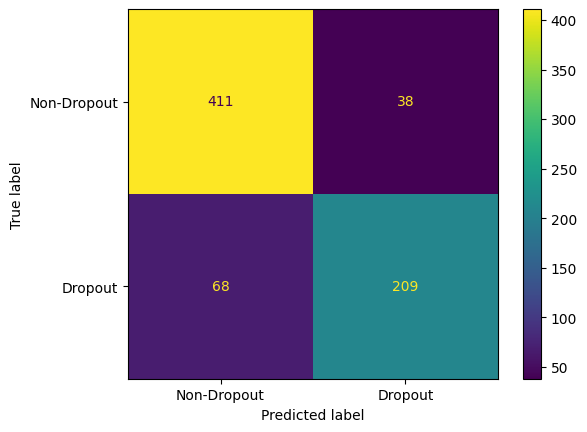

In [ ]:
y_pred_nb = grid_search_nb.predict(X_test)
perform(y_pred_nb)

### Logistic Regression

Precision :  0.9118457300275482
Recall :  0.9118457300275482
Accuracy :  0.9118457300275482
F1 Score :  0.9118457300275482

 [[427  22]
 [ 42 235]]


******************************************************
                Classification Report
******************************************************
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       449
           1       0.91      0.85      0.88       277

    accuracy                           0.91       726
   macro avg       0.91      0.90      0.91       726
weighted avg       0.91      0.91      0.91       726

******************************************************



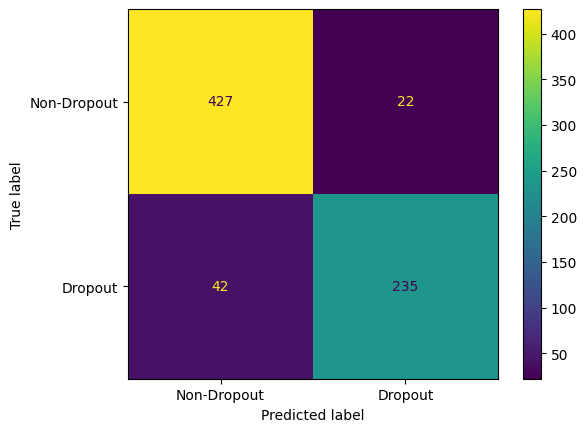

In [ ]:
y_pred_lr = grid_search_lr.predict(X_test)
perform(y_pred_lr)

### Random Forest

Precision :  0.9090909090909091
Recall :  0.9090909090909091
Accuracy :  0.9090909090909091
F1 Score :  0.9090909090909091

 [[429  20]
 [ 46 231]]


******************************************************
                Classification Report
******************************************************
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       449
           1       0.92      0.83      0.88       277

    accuracy                           0.91       726
   macro avg       0.91      0.89      0.90       726
weighted avg       0.91      0.91      0.91       726

******************************************************



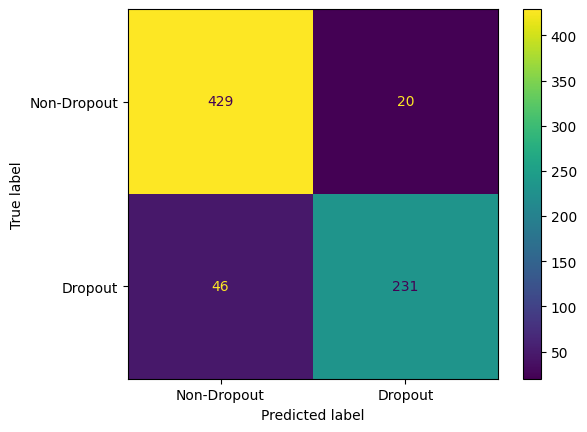

In [ ]:
y_pred_rf = grid_search_rf.predict(X_test)
perform(y_pred_rf)

XGBoost Classifier

Precision :  0.90633608815427
Recall :  0.90633608815427
Accuracy :  0.90633608815427
F1 Score :  0.90633608815427

 [[429  20]
 [ 48 229]]


******************************************************
                Classification Report
******************************************************
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       449
           1       0.92      0.83      0.87       277

    accuracy                           0.91       726
   macro avg       0.91      0.89      0.90       726
weighted avg       0.91      0.91      0.91       726

******************************************************



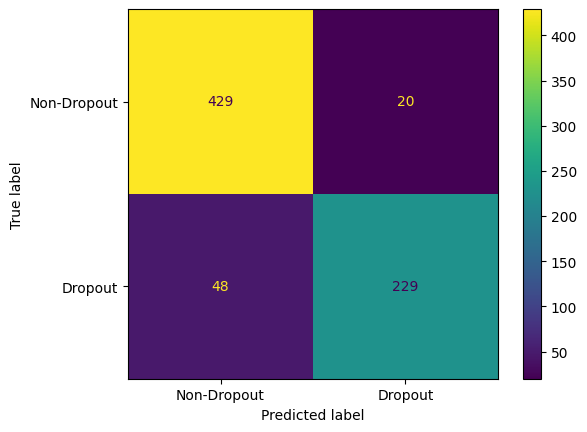

In [ ]:
y_pred_xgb = grid_search_xgb.predict(X_test)
perform(y_pred_xgb)

### Support Vector Classifier

Precision :  0.8994490358126722
Recall :  0.8994490358126722
Accuracy :  0.8994490358126722
F1 Score :  0.8994490358126722

 [[432  17]
 [ 56 221]]


******************************************************
                Classification Report
******************************************************
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       449
           1       0.93      0.80      0.86       277

    accuracy                           0.90       726
   macro avg       0.91      0.88      0.89       726
weighted avg       0.90      0.90      0.90       726

******************************************************



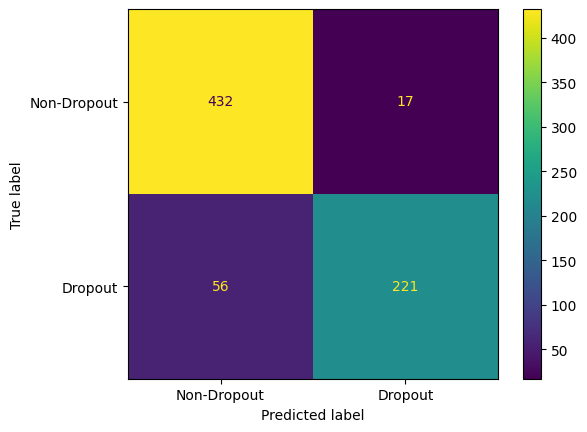

In [ ]:
y_pred_svc = grid_search_svc.predict(X_test)
perform(y_pred_svc)

### Precision-Recall Curve

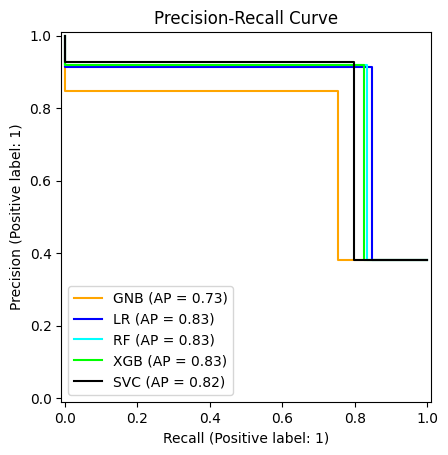

In [ ]:
fig, ax = plt.subplots()
plt.title("Precision-Recall Curve")
PrecisionRecallDisplay.from_predictions(y_test, y_pred_nb, ax = ax, name = "GNB", color='orange')
PrecisionRecallDisplay.from_predictions(y_test, y_pred_lr, ax = ax, name = "LR", color='blue')
PrecisionRecallDisplay.from_predictions(y_test, y_pred_rf, ax = ax, name = "RF", color='cyan')
PrecisionRecallDisplay.from_predictions(y_test, y_pred_xgb, ax = ax, name = "XGB", color='lime')
PrecisionRecallDisplay.from_predictions(y_test, y_pred_svc, ax = ax, name = "SVC", color='black')

### ROC Curve

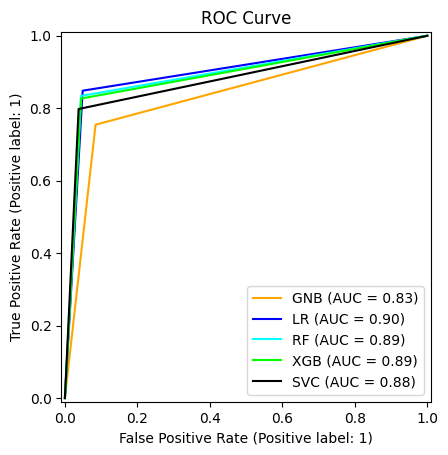

In [ ]:
fig, ax = plt.subplots()
plt.title("ROC Curve")
RocCurveDisplay.from_predictions(y_test, y_pred_nb, ax = ax, name = "GNB", color='orange')
RocCurveDisplay.from_predictions(y_test, y_pred_lr, ax = ax, name = "LR", color='blue')
RocCurveDisplay.from_predictions(y_test, y_pred_rf, ax = ax, name = "RF", color='cyan')
RocCurveDisplay.from_predictions(y_test, y_pred_xgb, ax = ax, name = "XGB", color='lime')
RocCurveDisplay.from_predictions(y_test, y_pred_svc, ax = ax, name = "SVC", color='black')

### Simpan Model Terbaik

| Model                | Accuracy | Precision | Recall | F1 Score |
|----------------------|----------|-----------|--------|----------|
| GaussianNB           | 0.85     | 0.85      | 0.85   | 0.85     |
| Logistic Regression  | 0.91     | 0.91      | 0.91   | 0.91     |
| Random Forest        | 0.90     | 0.90      | 0.90   | 0.90     |
| XGBoost              | 0.90     | 0.90      | 0.90   | 0.90     |
| SVC                  | 0.90     | 0.90      | 0.90   | 0.90     |

**Kesimpulan:**  
Model Logistic Regression memberikan performa terbaik secara keseluruhan pada data uji, diikuti oleh Random Forest, XGBoost, dan SVC. dan GaussianNB memiliki performa sedikit lebih rendah. Logistic Regression dipilih sebagai model akhir karena keseimbangan antara akurasi, precision, recall, dan f1-score.

Model yang disimpan pada tahap ini adalah model terbaik, yaitu Logistic Regression. Model ini dipilih berdasarkan hasil evaluasi performa pada data uji, di mana Logistic Regression menunjukkan keseimbangan terbaik antara akurasi, precision, recall, dan f1-score dibandingkan model lain yang diuji. Penyimpanan model ini memungkinkan penggunaan kembali untuk prediksi status mahasiswa di masa mendatang tanpa perlu melakukan pelatihan ulang.

In [ ]:
# Menyimpan model ke file dengan joblib
joblib.dump(best_model_lr, 'model/best_model_lr.joblib')
print("Model Logistic Regression berhasil disimpan ke 'model/best_model_lr.joblib'")

Model Logistic Regression berhasil disimpan ke 'model/best_model_lr.joblib'
